In [2]:
!pip install -q sentence-transformers scikit-learn numpy pandas matplotlib

In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

import time

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
sentences = [
    # Sports
    "The football team won the match after scoring two goals.",
    "The basketball player practiced shooting before the game.",
    "The tennis player trained hard for the championship.",
    "The cricket team celebrated their victory after the final over.",
    "The athlete prepared for the upcoming running competition.",

    # Technology
    "Python is widely used for data analysis and machine learning.",
    "Artificial intelligence helps computers understand complex patterns.",
    "Cloud computing allows applications to run on remote servers.",
    "Cybersecurity protects computer systems from digital attacks.",
    "Machine learning models learn useful patterns from data.",

    # Cooking
    "The chef prepared a delicious vegetable soup for dinner.",
    "Fresh vegetables make the salad healthy and colorful.",
    "The recipe requires flour, eggs, and milk to make a cake.",
    "The cook added spices to improve the flavor of the dish.",
    "Baking bread requires mixing flour with water and yeast.",

    # Travel
    "We visited the beautiful mountains during our vacation.",
    "The travelers booked a hotel near the airport.",
    "The family enjoyed exploring historical places in the city.",
    "The airplane arrived at the destination after a long journey.",
    "Tourists took photographs while visiting the famous beach."
]

topics = [
    "Sports", "Sports", "Sports", "Sports", "Sports",
    "Technology", "Technology", "Technology", "Technology", "Technology",
    "Cooking", "Cooking", "Cooking", "Cooking", "Cooking",
    "Travel", "Travel", "Travel", "Travel", "Travel"
]

print("Total sentences:", len(sentences))

Total sentences: 20


In [5]:
start_time = time.time()

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(sentences)

end_time = time.time()

generation_time = end_time - start_time

print("Number of embeddings:", len(embeddings))
print("Embedding dimensions:", embeddings.shape[1])
print("Generation time:", round(generation_time, 4), "seconds")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Number of embeddings: 20
Embedding dimensions: 384
Generation time: 5.6169 seconds


In [6]:
def cosine_score(i, j):
    return cosine_similarity(
        embeddings[i].reshape(1, -1),
        embeddings[j].reshape(1, -1)
    )[0][0]

score = cosine_score(0, 1)

print("Sentence 1:", sentences[0])
print("Sentence 2:", sentences[1])
print("Cosine similarity:", round(score, 4))

Sentence 1: The football team won the match after scoring two goals.
Sentence 2: The basketball player practiced shooting before the game.
Cosine similarity: 0.0818


In [7]:
paraphrase_pairs = [
    ("The football team won the match.",
     "The soccer team achieved victory in the game."),

    ("Python is useful for analyzing data.",
     "Python helps us examine information efficiently."),

    ("The chef prepared a tasty meal.",
     "The cook made a delicious dish."),

    ("We traveled to the mountains during our vacation.",
     "We went to the hills on our holiday."),

    ("The airplane reached its destination.",
     "The aircraft arrived at the final location.")
]

pair_sentences = [sentence for pair in paraphrase_pairs for sentence in pair]

print("Total comparison sentences:", len(pair_sentences))

Total comparison sentences: 10


In [8]:
tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(pair_sentences)

tfidf_scores = []

for i in range(0, 10, 2):
    score = cosine_similarity(
        tfidf_matrix[i],
        tfidf_matrix[i + 1]
    )[0][0]

    tfidf_scores.append(score)

for i, score in enumerate(tfidf_scores, 1):
    print(f"Pair {i} TF-IDF similarity: {score:.4f}")

Pair 1 TF-IDF similarity: 0.2788
Pair 2 TF-IDF similarity: 0.1263
Pair 3 TF-IDF similarity: 0.0470
Pair 4 TF-IDF similarity: 0.3716
Pair 5 TF-IDF similarity: 0.0800


In [9]:
pair_embeddings = model.encode(pair_sentences)

embedding_scores = []

for i in range(0, 10, 2):
    score = cosine_similarity(
        pair_embeddings[i].reshape(1, -1),
        pair_embeddings[i + 1].reshape(1, -1)
    )[0][0]

    embedding_scores.append(score)

for i, score in enumerate(embedding_scores, 1):
    print(f"Pair {i} Embedding similarity: {score:.4f}")

Pair 1 Embedding similarity: 0.6897
Pair 2 Embedding similarity: 0.8416
Pair 3 Embedding similarity: 0.7789
Pair 4 Embedding similarity: 0.6308
Pair 5 Embedding similarity: 0.7846


In [10]:
comparison = pd.DataFrame({
    "Pair": range(1, 6),
    "Sentence 1": [pair[0] for pair in paraphrase_pairs],
    "Sentence 2": [pair[1] for pair in paraphrase_pairs],
    "TF-IDF Similarity": tfidf_scores,
    "Embedding Similarity": embedding_scores
})

comparison

,Pair,Sentence 1,Sentence 2,TF-IDF Similarity,Embedding Similarity
0,1,The football team won the match.,The soccer team achieved victory in the game.,0.278792,0.689667
1,2,Python is useful for analyzing data.,Python helps us examine information efficiently.,0.126280,0.841582
2,3,The chef prepared a tasty meal.,The cook made a delicious dish.,0.046951,0.778851
3,4,We traveled to the mountains during our vacation.,We went to the hills on our holiday.,0.371566,0.630751
4,5,The airplane reached its destination.,The aircraft arrived at the final location.,0.079961,0.784565


In [11]:
def embed_and_recommend(query_sentence, corpus_sentences):

    query_embedding = model.encode([query_sentence])

    corpus_embeddings = model.encode(corpus_sentences)

    scores = cosine_similarity(
        query_embedding,
        corpus_embeddings
    )[0]

    top_indices = np.argsort(scores)[::-1][:3]

    recommendations = []

    for index in top_indices:
        recommendations.append(
            (corpus_sentences[index], scores[index])
        )

    return recommendations

In [12]:
query = "A computer system can learn patterns from information."

results = embed_and_recommend(
    query,
    sentences
)

print("Query:", query)
print("\nTop 3 semantically similar sentences:\n")

for sentence, score in results:
    print(f"{score:.4f} → {sentence}")

Query: A computer system can learn patterns from information.

Top 3 semantically similar sentences:

0.7023 → Artificial intelligence helps computers understand complex patterns.
0.6081 → Machine learning models learn useful patterns from data.
0.3695 → Cybersecurity protects computer systems from digital attacks.


In [13]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(embeddings)

cluster_results = pd.DataFrame({
    "Sentence": sentences,
    "Original Topic": topics,
    "Cluster": cluster_labels
})

cluster_results

,Sentence,Original Topic,Cluster
0,The football team won the match after scoring ...,Sports,2
1,The basketball player practiced shooting befor...,Sports,2
2,The tennis player trained hard for the champio...,Sports,2
3,The cricket team celebrated their victory afte...,Sports,2
4,The athlete prepared for the upcoming running ...,Sports,2
5,Python is widely used for data analysis and ma...,Technology,0
6,Artificial intelligence helps computers unders...,Technology,0
7,Cloud computing allows applications to run on ...,Technology,0
8,Cybersecurity protects computer systems from d...,Technology,0
9,Machine learning models learn useful patterns ...,Technology,0


In [14]:
for cluster in sorted(cluster_results["Cluster"].unique()):

    print(f"\n===== Cluster {cluster} =====")

    cluster_data = cluster_results[
        cluster_results["Cluster"] == cluster
    ]

    for _, row in cluster_data.iterrows():
        print(f"{row['Original Topic']} → {row['Sentence']}")


===== Cluster 0 =====
Technology → Python is widely used for data analysis and machine learning.
Technology → Artificial intelligence helps computers understand complex patterns.
Technology → Cloud computing allows applications to run on remote servers.
Technology → Cybersecurity protects computer systems from digital attacks.
Technology → Machine learning models learn useful patterns from data.

===== Cluster 1 =====
Travel → We visited the beautiful mountains during our vacation.
Travel → The travelers booked a hotel near the airport.
Travel → The family enjoyed exploring historical places in the city.
Travel → The airplane arrived at the destination after a long journey.
Travel → Tourists took photographs while visiting the famous beach.

===== Cluster 2 =====
Sports → The football team won the match after scoring two goals.
Sports → The basketball player practiced shooting before the game.
Sports → The tennis player trained hard for the championship.
Sports → The cricket team cele

In [15]:
cluster_topic_table = pd.crosstab(
    cluster_results["Cluster"],
    cluster_results["Original Topic"]
)

print("Cluster vs Topic:")
cluster_topic_table

Cluster vs Topic:


Original Topic,Cooking,Sports,Technology,Travel
Cluster,,,,
0,0,0,5,0
1,0,0,0,5
2,0,5,0,0
3,5,0,0,0


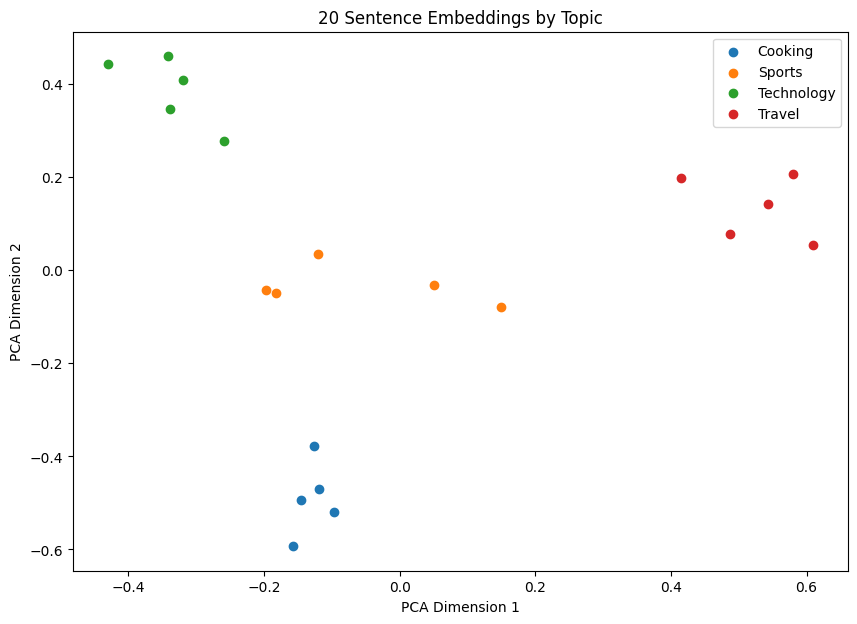

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embedding_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 7))

for topic in sorted(set(topics)):
    indices = [
        i for i, t in enumerate(topics)
        if t == topic
    ]

    plt.scatter(
        embedding_2d[indices, 0],
        embedding_2d[indices, 1],
        label=topic
    )

plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.title("20 Sentence Embeddings by Topic")
plt.legend()
plt.show()

TF-IDF represents text using word frequency and vocabulary overlap. It works well when important words are shared between documents.

Dense embeddings represent sentences as numerical vectors that capture semantic meaning. Therefore, sentences with different words can still have high similarity when their meanings are related.

TF-IDF is useful for keyword-based matching, while dense embeddings are useful for semantic search, recommendations, clustering, and paraphrase detection.

In this task, cosine similarity was used to compare sentence embeddings, and K-Means clustering was used to group the 20 sentences into 4 clusters.